# DSCI235 Final Project

https://github.com/CoderCat21/DSCI235Final

### Introduction
In this project, I want to analyze how the climate indicators of sea level, surface temperature, and natural disaster count / frequency are affected by changes in greenhouse gas concentrations in the atmosphere. I am also interested in seeing if particular locations on the earth are more strongly affected by GHG concentrations.

This can be especially insightful when it comes to preparing for changes in climate, as it can help determine which regions need special attention.

I wanted to analyze the change in regards to population growth, but it seems like it might be difficult to thoroughly consider in addition to the other climate indicators. We know that world populations are increasing, and this is one of the most significant factors that contributes to the rise in atmospheric GHG levels with fossil fuel use.

My first dataset for Atmospheric GHG Concentration comes from the KAPSARC Data Portal:

https://datasource.kapsarc.org/explore/assets/atmospheric-ghg-concentrations/

The other datasets contain Climate Change Data from the IMF Macroeconomic Climate Indicators Dashboard:

https://climatedata.imf.org/pages/climatechange-data





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Cleaning

I'm gathering data from multiple datasets since there are a number of climate indicators that can be influenced by GHG concentration. I will start by isolating the specific data I plan to use from each of my datasets. Then, I will sort and organize the data so it's simpler to analyze specific aspects.

This first dataset contains information about atmospheric GHG concentrations in previous years, and it will guide our conclusions when compared to data from the other datasets.

In [ ]:
ghg_data = pd.read_csv("https://datasource.kapsarc.org/api/explore/v2.1/catalog/datasets/atmospheric-ghg-concentrations/exports/csv/?delimiter=%3B&lang=en&timezone=America%2FChicago&use_labels=true", delimiter=';', header=None, names=['Year', 'GHG', 'Column3', 'Column4'], skiprows=1)
ghg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Year     68 non-null     int64  
 1   GHG      68 non-null     float64
 2   Column3  68 non-null     int64  
 3   Column4  68 non-null     int64  
dtypes: float64(1), int64(3)
memory usage: 2.3 KB


In [ ]:
ghg_data = ghg_data.set_index("Year")
ghg_data = ghg_data.drop(['Column3', 'Column4'], axis=1)
ghg_data

# we read in the data for world greenhouse gas concentrations over the years, dropping data that is not necessary and renaming the columns for easier reference

,GHG
Year,
1900,287.65
1910,283.98
1925,291.48
1978,310.50
1983,324.07
...,...
1981,318.36
1982,320.96
2003,394.13


This second dataset contains info about annual changes in surface temperature for different countries and continents.

In [ ]:
surf_temp_change_data = pd.read_csv('https://opendata.arcgis.com/datasets/4063314923d74187be9596f10d034914_0.csv')
surf_temp_change_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231 entries, 0 to 230
Data columns (total 74 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ObjectId             231 non-null    int64  
 1   Country              231 non-null    object 
 2   ISO2                 224 non-null    object 
 3   ISO3                 231 non-null    object 
 4   Indicator            231 non-null    object 
 5   Unit                 231 non-null    object 
 6   Source               231 non-null    object 
 7   CTS Code             231 non-null    object 
 8   CTS Name             231 non-null    object 
 9   CTS Full Descriptor  231 non-null    object 
 10  1961                 194 non-null    float64
 11  1962                 196 non-null    float64
 12  1963                 195 non-null    float64
 13  1964                 194 non-null    float64
 14  1965                 194 non-null    float64
 15  1966                 198 non-null    flo

In [ ]:
surf_temp_change_data.head()

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS Code,CTS Name,CTS Full Descriptor,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,1,"Afghanistan, Islamic Rep. of",AF,AFG,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,1.139,1.588,1.630,1.597,0.951,0.552,1.418,1.967,1.748,2.188
1,2,Africa,NaN,AFRTMP,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,1.195,1.385,1.158,1.150,1.290,1.177,1.400,1.014,1.485,1.750
2,3,Albania,AL,ALB,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,1.702,1.608,1.239,2.155,1.797,1.627,1.719,1.701,2.299,2.925
3,4,Algeria,DZ,DZA,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,1.134,1.761,1.506,1.203,1.240,2.006,2.424,1.804,2.303,2.824
4,5,American Samoa,AS,ASM,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,0.738,1.268,1.163,0.917,1.268,1.159,0.997,0.984,1.010,1.588


In [ ]:
surf_temp_change_data = surf_temp_change_data.drop(['ObjectId','ISO2',	'ISO3',	'Indicator',	'Unit',	'Source',	'CTS Code',	'CTS Name',	'CTS Full Descriptor'], axis=1)

surf_temp_change_data = surf_temp_change_data.set_index(['Country'])
surf_temp_change_data = surf_temp_change_data.transpose()

In [ ]:
surf_temp_change_data.head()

Country,"Afghanistan, Islamic Rep. of",Africa,Albania,Algeria,American Samoa,Americas,"Andorra, Principality of",Angola,Anguilla,Antigua and Barbuda,...,Vanuatu,"Venezuela, Rep. Bolivariana de",Vietnam,Wallis and Futuna Islands,West Bank and Gaza,Western Sahara,World,"Yemen, Rep. of",Zambia,Zimbabwe
1961,-0.096,-0.015,0.643,0.154,0.075,0.058,0.736,0.033,-0.029,0.013,...,0.179,0.023,0.038,0.329,-0.109,0.633,0.206,0.061,0.237,0.253
1962,-0.143,-0.033,0.351,0.105,-0.047,-0.087,0.109,-0.159,-0.046,-0.025,...,0.101,-0.180,-0.215,-0.045,0.803,0.572,0.031,0.018,-0.149,0.222
1963,0.848,0.069,0.089,0.072,0.161,0.271,-0.759,-0.195,0.192,0.228,...,-0.157,-0.041,-0.283,0.131,0.834,0.351,0.175,0.203,-0.367,-0.462
1964,-0.762,-0.149,-0.154,0.248,-0.146,-0.248,0.303,-0.231,0.099,0.093,...,0.228,0.033,0.086,0.190,-0.642,0.841,-0.251,-0.215,-0.258,-0.097
1965,-0.233,-0.194,-0.377,-0.104,-0.538,-0.373,-0.501,-0.200,-0.334,-0.378,...,-0.517,-0.163,-0.020,-0.408,-0.034,-0.305,-0.251,-0.591,-0.390,-0.471


Now, we can see surface temp change data over time for the "World" or any particular country we select.

This third dataset contains info about changes in mean sea level each year for different countries and continents.

In [ ]:
meansealevel_change_data = pd.read_csv('https://opendata.arcgis.com/datasets/b84a7e25159b4c65ba62d3f82c605855_0.csv')
meansealevel_change_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41693 entries, 0 to 41692
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ObjectId             41693 non-null  int64  
 1   Country              41693 non-null  object 
 2   ISO2                 0 non-null      float64
 3   ISO3                 41693 non-null  object 
 4   Indicator            41693 non-null  object 
 5   Unit                 41693 non-null  object 
 6   Source               41693 non-null  object 
 7   CTS Code             41693 non-null  object 
 8   CTS Name             41693 non-null  object 
 9   CTS Full Descriptor  41693 non-null  object 
 10  Measure              41693 non-null  object 
 11  Date                 41693 non-null  object 
 12  Value                41693 non-null  float64
dtypes: float64(2), int64(1), object(10)
memory usage: 4.1+ MB


In [ ]:
meansealevel_change_data.drop(['ObjectId','ISO2',	'ISO3',	'Indicator',	'Unit',	'Source',	'CTS Code',	'CTS Name',	'CTS Full Descriptor'], axis=1, inplace=True)

meansealevel_change_data.drop(['Country'], axis=1, inplace=True)
meansealevel_change_data['Year'] = meansealevel_change_data['Date'].str[-4:]

meansealevel_change_data.set_index(['Year','Measure'], inplace=True)

meansealevel_change_data

Date  Value
Year Measure                           
1992 Arabian Sea     D10/17/1992 -62.50
     Atlantic Ocean  D10/17/1992   2.91
     Bay Bengal      D10/17/1992  10.31
     Bering Sea      D10/17/1992  33.85
     Caribbean Sea   D10/17/1992  75.12
...                          ...    ...
2025 South China     D02/18/2025   4.02
     Southern Ocean  D02/18/2025   3.05
     Tropics         D02/18/2025   3.27
     World           D02/18/2025   3.17
     Yellow Sea      D02/18/2025   3.33

[41693 rows x 2 columns]

In [ ]:
msl_chg_data = meansealevel_change_data.xs('World', level=1)
msl_chg_data

,Date,Value
Year,,
1992,D12/17/1992,-14.63
1992,D12/27/1992,-19.23
1993,D01/05/1993,-22.03
1993,D01/15/1993,-23.33
1993,D01/24/1993,-24.63
...,...,...
2025,D01/18/2025,84.70
2025,D01/28/2025,82.60
2025,D02/07/2025,81.70


In [ ]:
msl_chg_data_i = msl_chg_data.copy()
msl_chg_data_i.index = range(len(msl_chg_data_i))

msl_chg_data_i

,Date,Value
0,D12/17/1992,-14.63
1,D12/27/1992,-19.23
2,D01/05/1993,-22.03
3,D01/15/1993,-23.33
4,D01/24/1993,-24.63
...,...,...
1653,D01/18/2025,84.70
1654,D01/28/2025,82.60
1655,D02/07/2025,81.70
1656,D02/16/2025,82.40


Lastly, this fourth dataset contains info about natural disaster frequency in different countries over time.

In [ ]:
ndf_data = pd.read_csv('https://opendata.arcgis.com/datasets/b13b69ee0dde43a99c811f592af4e821_0.csv')
ndf_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1972 entries, 0 to 1971
Data columns (total 55 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ObjectId             1972 non-null   int64  
 1   Country              1972 non-null   object 
 2   ISO2                 1920 non-null   object 
 3   ISO3                 1972 non-null   object 
 4   Indicator            1972 non-null   object 
 5   Unit                 1972 non-null   object 
 6   Source               1972 non-null   object 
 7   CTS Code             986 non-null    object 
 8   CTS Name             986 non-null    object 
 9   CTS Full Descriptor  986 non-null    object 
 10  1980                 238 non-null    float64
 11  1981                 262 non-null    float64
 12  1982                 278 non-null    float64
 13  1983                 378 non-null    float64
 14  1984                 272 non-null    float64
 15  1985                 286 non-null    f

In [ ]:
ndf_data.head()

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS Code,CTS Name,CTS Full Descriptor,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,1,"Afghanistan, Islamic Rep. of",AF,AFG,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",ECCD,Climate Related Disasters Frequency,"Environment, Climate Change, Adaptation, Clima...",...,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN
1,2,"Afghanistan, Islamic Rep. of",AF,AFG,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",ECCD,Climate Related Disasters Frequency,"Environment, Climate Change, Adaptation, Clima...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
2,3,"Afghanistan, Islamic Rep. of",AF,AFG,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",ECCD,Climate Related Disasters Frequency,"Environment, Climate Change, Adaptation, Clima...",...,1.0,4.0,1.0,3.0,6.0,5.0,2.0,5.0,2.0,5.0
3,4,"Afghanistan, Islamic Rep. of",AF,AFG,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",ECCD,Climate Related Disasters Frequency,"Environment, Climate Change, Adaptation, Clima...",...,4.0,NaN,2.0,1.0,1.0,1.0,1.0,1.0,NaN,2.0
4,5,"Afghanistan, Islamic Rep. of",AF,AFG,"Climate related disasters frequency, Number of...",Number of,"The Emergency Events Database (EM-DAT) , Centr...",ECCD,Climate Related Disasters Frequency,"Environment, Climate Change, Adaptation, Clima...",...,NaN,NaN,2.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN


In [ ]:
ndf_data['Indicator'].unique()

array(['Climate related disasters frequency, Number of Disasters: Drought',
       'Climate related disasters frequency, Number of Disasters: Extreme temperature',
       'Climate related disasters frequency, Number of Disasters: Flood',
       'Climate related disasters frequency, Number of Disasters: Landslide',
       'Climate related disasters frequency, Number of Disasters: Storm',
       'Climate related disasters frequency, Number of Disasters: TOTAL',
       'Climate related disasters frequency, Number of Disasters: Wildfire',
       'Climate related disasters frequency, Number of People Affected: Drought',
       'Climate related disasters frequency, Number of People Affected: Extreme temperature',
       'Climate related disasters frequency, Number of People Affected: Flood',
       'Climate related disasters frequency, Number of People Affected: Landslide',
       'Climate related disasters frequency, Number of People Affected: Storm',
       'Climate related disasters frequ

In [ ]:
# delete all except country, indicator, years
# set index to country, then indicator
# then transpose

ndf_data2 = ndf_data.drop(['ObjectId','ISO2',	'ISO3',		'Unit',	'Source',	'CTS Code',	'CTS Name',	'CTS Full Descriptor'], axis=1)
ndf_data2.set_index(['Country', 'Indicator'], inplace=True)
ndf_data2 = ndf_data2.transpose()
ndf_data2.head()


Country                                        Afghanistan, Islamic Rep. of  \
Indicator Climate related disasters frequency, Number of Disasters: Drought   
1980                                                     NaN                  
1981                                                     NaN                  
1982                                                     NaN                  
1983                                                     NaN                  
1984                                                     NaN                  

Country                                                                                  \
Indicator Climate related disasters frequency, Number of Disasters: Extreme temperature   
1980                                                     NaN                              
1981                                                     NaN                              
1982                                                     NaN                              
1983                                                     NaN                              
1984                                                     NaN                              

Country                                                                    \
Indicator Climate related disasters frequency, Number of Disasters: Flood   
1980                                                     1.0                
1981                                                     NaN                
1982                                                     NaN                
1983                                                     NaN                
1984                                                     NaN                

Country                                                                        \
Indicator Climate related disasters frequency, Number of Disasters: Landslide   
1980                                                     NaN                    
1981                                                     NaN                    
1982                                                     NaN                    
1983                                                     NaN                    
1984                                                     NaN                    

Country                                                                    \
Indicator Climate related disasters frequency, Number of Disasters: Storm   
1980                                                     NaN                
1981                                                     NaN                
1982                                                     NaN                
1983                                                     NaN                
1984                                                     NaN                

Country                                                                    \
Indicator Climate related disasters frequency, Number of Disasters: TOTAL   
1980                                                     1.0                
1981                                                     NaN                
1982                                                     NaN                
1983                                                     NaN                
1984                                                     NaN                

Country                                                                       \
Indicator Climate related disasters frequency, Number of Disasters: Wildfire   
1980                                                     NaN                   
1981                                                     NaN                   
1982                                                     NaN                   
1983                                                     NaN                   
1984                                                     NaN                   

Country                                                    

In [ ]:
ndf_data3 = ndf_data.drop(['ObjectId','ISO2',	'ISO3',		'Unit',	'Source',	'CTS Code',	'CTS Name',	'CTS Full Descriptor'], axis=1)
ndf_data3.set_index(['Country', 'Indicator'], inplace=True)
ndf_data3 = ndf_data3.transpose()
ndf_data3 = ndf_data3.stack(level='Country')
ndf_data3.head()

/tmp/ipykernel_19324/2951649057.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ndf_data3 = ndf_data3.stack(level='Country')


Indicator                          Climate related disasters frequency, Number of Disasters: Drought  \
     Country                                                                                           
1980 Afghanistan, Islamic Rep. of                                                NaN                   
     Argentina                                                                   NaN                   
     Austria                                                                     NaN                   
     Bangladesh                                                                  NaN                   
     Barbados                                                                    NaN                   

Indicator                          Climate related disasters frequency, Number of Disasters: Extreme temperature  \
     Country                                                                                                       
1980 Afghanistan, Islamic Rep. of                                                NaN                               
     Argentina                                                                   NaN                               
     Austria                                                                     NaN                               
     Bangladesh                                                                  NaN                               
     Barbados                                                                    NaN                               

Indicator                          Climate related disasters frequency, Number of Disasters: Flood  \
     Country                                                                                         
1980 Afghanistan, Islamic Rep. of                                                1.0                 
     Argentina                                                                   2.0                 
     Austria                                                                     1.0                 
     Bangladesh                                                                  1.0                 
     Barbados                                                                    NaN                 

Indicator                          Climate related disasters frequency, Number of Disasters: Landslide  \
     Country                                                                                             
1980 Afghanistan, Islamic Rep. of                                                NaN                     
     Argentina                                                                   NaN                     
     Austria                                                                     NaN                     
     Bangladesh                                                                  NaN                     
     Barbados                                                                    NaN                     

Indicator                          Climate related disasters frequency, Number of Disasters: Storm  \
     Country                                                                                         
1980 Afghanistan, Islamic Rep. of                                                NaN                 
     Argentina                                                                   NaN                 
     Austria                                                                     NaN                 
     Bangladesh                                                                  1.0                 
     Barbados                                                                    1.0                 

Indicator                          Climate related disasters frequency, Number of Disasters: TOTAL  \
     Country                                                                                         
1980 Afghanistan, Islamic Rep. of                                                

In [ ]:
ndf_data2.columns.unique(level=0).tolist()

['Afghanistan, Islamic Rep. of',
 'Albania',
 'Algeria',
 'American Samoa',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia, Rep. of',
 'Australia',
 'Austria',
 'Azerbaijan, Rep. of',
 'Azores Island',
 'Bahamas, The',
 'Bangladesh',
 'Barbados',
 'Belarus, Rep. of',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei Darussalam',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cabo Verde',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Canary Island',
 'Cayman Islands',
 'Central African Rep.',
 'Chad',
 'Chile',
 'China, P.R.: Hong Kong',
 'China, P.R.: Macao',
 'China, P.R.: Mainland',
 'Colombia',
 'Comoros, Union of the',
 'Congo, Dem. Rep. of the',
 'Congo, Rep. of',
 'Cook Islands',
 'Costa Rica',
 "Côte d'Ivoire",
 'Croatia, Rep. of',
 'Cuba',
 'Cyprus',
 'Czech Rep.',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Rep.',
 'Ecuador',
 'Egypt, Arab Rep. of',
 'E

Now that we're more familiar with each dataset and what can be isolated from it, we can analyze them more effectively.

## Exploring GHG Impact on Surface Temperature

This first plot shows the world GHG concentration over time. We will compare this to the changes in surface temperature, sea level, and natural disaster frequency, looking for a correlation.

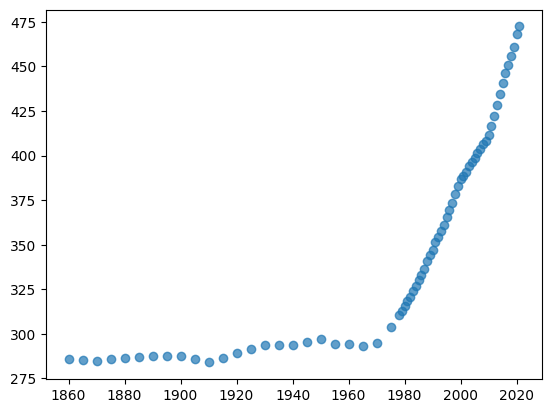

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()

ax.scatter(ghg_data.index, ghg_data, alpha=0.7)

This shows that world GHG concentrations have increased as the years went by.

Next, let's look to see if this same trend is present when comparing world GHG concentration to surface temp changes for the world and particular countries/continents.

Text(0, 0.5, 'Change in Degrees Celsius')

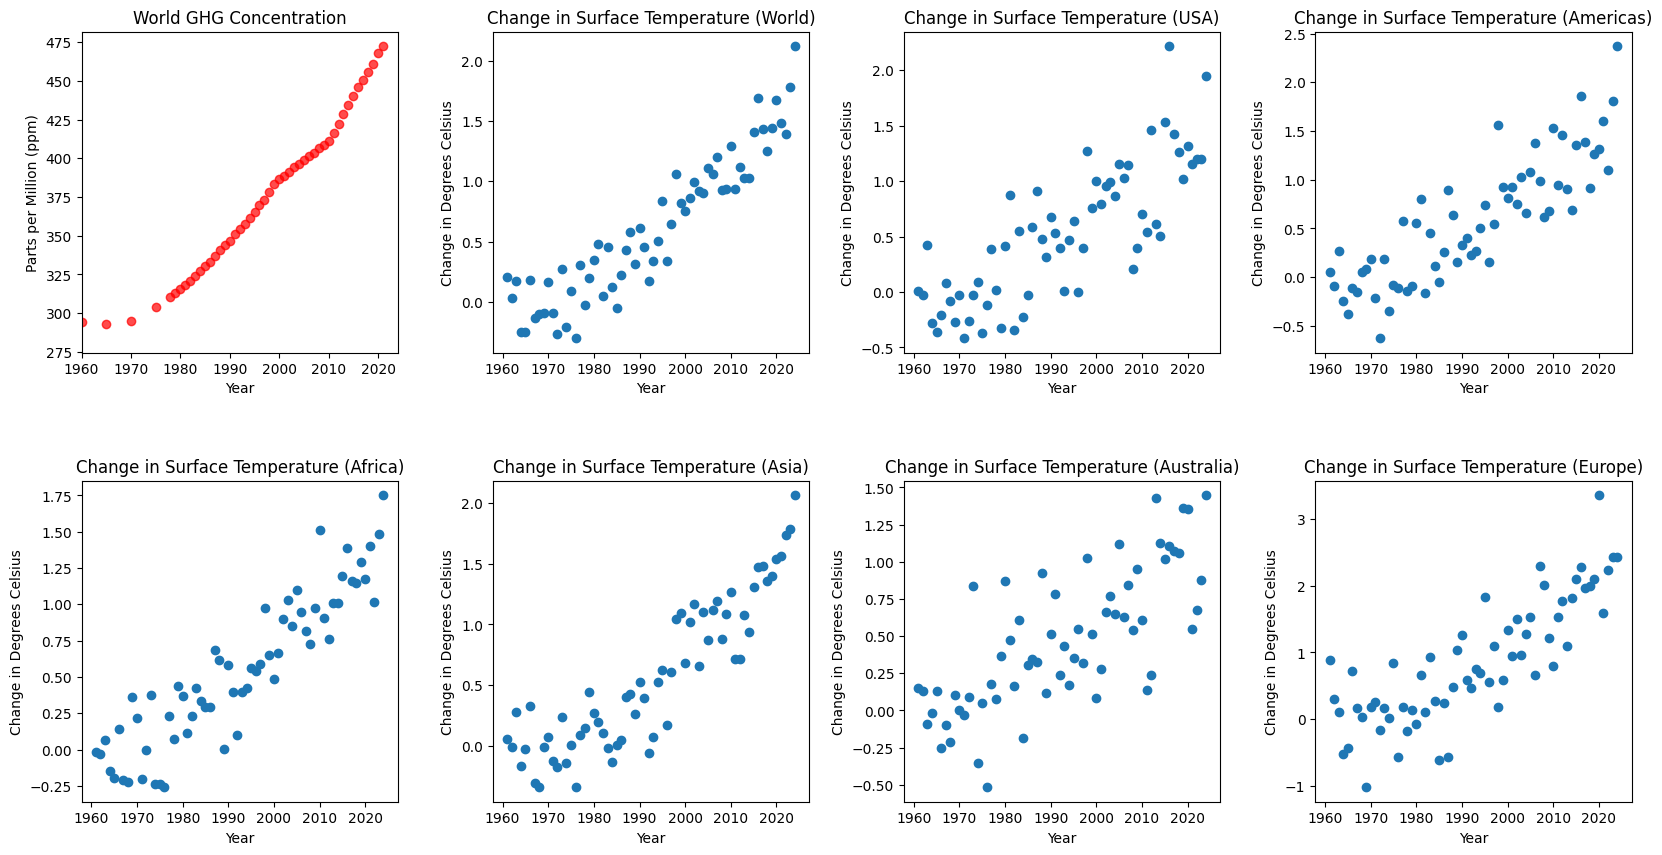

In [ ]:
surf_temp_change_data.index = surf_temp_change_data.index.astype(int)

fig = plt.figure(figsize=(20, 10))

ax1 = fig.add_subplot(2, 4, 1)
ax2 = fig.add_subplot(2, 4, 2)
ax3 = fig.add_subplot(2, 4, 3)
ax4 = fig.add_subplot(2, 4, 4)
ax5 = fig.add_subplot(2, 4, 5)
ax6 = fig.add_subplot(2, 4, 6)
ax7 = fig.add_subplot(2, 4, 7)
ax8 = fig.add_subplot(2, 4, 8)

plt.subplots_adjust(hspace=0.4, wspace=0.3)

ax1.scatter(ghg_data.index, ghg_data, alpha=0.7, color='red')
ax1.set_title("World GHG Concentration")
ax1.set_xlabel('Year')
ax1.set_ylabel('Parts per Million (ppm)')
ax1.set_xlim(1960, 2024)

ax2.scatter(surf_temp_change_data.index, surf_temp_change_data['World'])
ax2.set_title('Change in Surface Temperature (World)')
ax2.set_xlabel('Year')
ax2.set_ylabel('Change in Degrees Celsius')

ax3.scatter(surf_temp_change_data.index, surf_temp_change_data['United States'])
ax3.set_title('Change in Surface Temperature (USA)')
ax3.set_xlabel('Year')
ax3.set_ylabel('Change in Degrees Celsius')

ax4.scatter(surf_temp_change_data.index, surf_temp_change_data['Americas'])
ax4.set_title('Change in Surface Temperature (Americas)')
ax4.set_xlabel('Year')
ax4.set_ylabel('Change in Degrees Celsius')

ax5.scatter(surf_temp_change_data.index, surf_temp_change_data['Africa'])
ax5.set_title('Change in Surface Temperature (Africa)')
ax5.set_xlabel('Year')
ax5.set_ylabel('Change in Degrees Celsius')

ax6.scatter(surf_temp_change_data.index, surf_temp_change_data['Asia'])
ax6.set_title('Change in Surface Temperature (Asia)')
ax6.set_xlabel('Year')
ax6.set_ylabel('Change in Degrees Celsius')

ax7.scatter(surf_temp_change_data.index, surf_temp_change_data['Australia'])
ax7.set_title('Change in Surface Temperature (Australia)')
ax7.set_xlabel('Year')
ax7.set_ylabel('Change in Degrees Celsius')

ax8.scatter(surf_temp_change_data.index, surf_temp_change_data['Europe'])
ax8.set_title('Change in Surface Temperature (Europe)')
ax8.set_xlabel('Year')
ax8.set_ylabel('Change in Degrees Celsius')

I decided to make scatter plots instead of line plots so that the variations from year to year don't obscure the overall trend that is to be seen. I also realize that the scales are different, but the key idea is that all the plotted locations show an increase in surface temperature.

Based on these plots, the same trend is visible across many continents, giving a lot of credence to the idea that temperatures in all areas of the globe are affected by increases in GHG world concentrations.

However, are any particular places affected more?

To answer this, we can look at which locations rank the highest in terms of overall change in surface temp.
Since there are so many countries, we can compare by continents as above.

<Axes: xlabel='Country'>

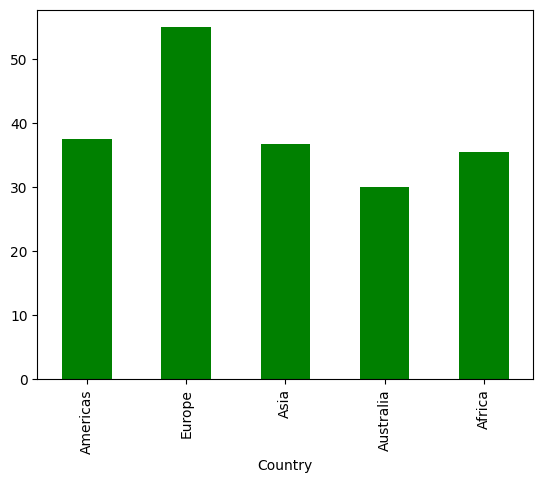

In [ ]:
country_list = ['Americas', 'Europe', 'Asia', 'Australia', 'Africa']
stc_cont_sums = surf_temp_change_data[country_list].sum()
stc_cont_sums.plot(kind='bar', color='green')

Overall, this shows that Europe has seen a greater increase in surface temperature than the other continents. Actually, based on the chart, the surface temperature for Europe has increased over 15C higher from 1960 to 2024 than the other continent in the same period of time!


## Exploring GHG Impact on Sea Level

Next, we'll look at the changes in mean sea level.

Text(0, 0.5, 'Sea Level Change (units)')

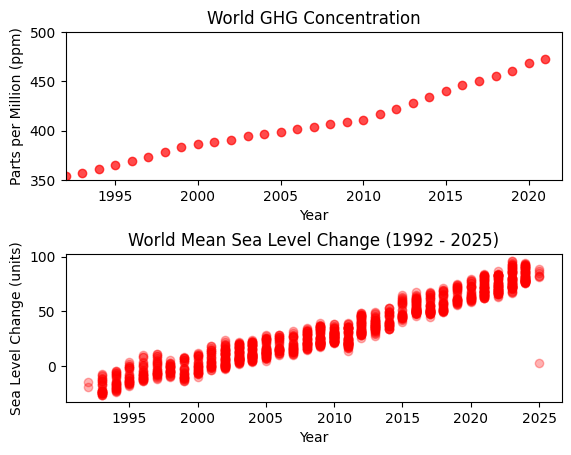

In [ ]:
msl_chg_data.index = msl_chg_data.index.astype(int)

fig = plt.figure()
ax1 = fig.add_subplot(2,1,1)
ax2 = fig.add_subplot(2,1,2)

plt.subplots_adjust(hspace=0.5)

ax1.scatter(ghg_data.index, ghg_data, alpha=0.7, color='red')
ax1.set_title("World GHG Concentration")
ax1.set_xlabel('Year')
ax1.set_ylabel('Parts per Million (ppm)')
ax1.set_xlim(left=1992, right=2022)
ax1.set_ylim(350,500)

ax2.scatter(msl_chg_data.index, msl_chg_data['Value'], alpha=0.3, color='red')
ax2.set_title("World Mean Sea Level Change (1992 - 2025)")
ax2.set_xlabel("Year")
ax2.set_ylabel("Sea Level Change (units)")

The sea level change plot appears to have vertical lines since there were multiple measurements for each year.

Looking at these plots, we also see a correlation between GHG concentration and mean sea level change on a global scale. The sea level chnage during each year is growing with each passing year.

Now, let's see how the total change in sea level since 1992 varies among the different oceans and seas.

<Axes: title={'center': 'Total Sea Level Change Since 1992'}, ylabel='Seas / Oceans'>

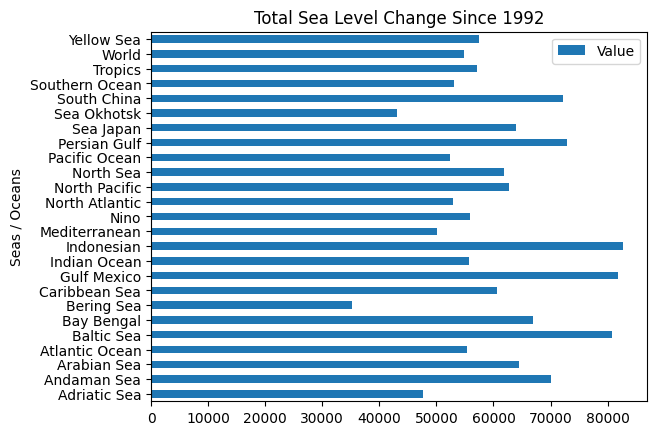

In [ ]:
msl_data2 = meansealevel_change_data.reset_index(level='Year')
msl_data2.drop(columns=['Year','Date'], inplace=True)
msl_data2_sums = msl_data2.groupby(msl_data2.index).sum()
msl_data2_sums.plot(kind='barh', ylabel='Seas / Oceans', title='Total Sea Level Change Since 1992')

Here, we see that the Indonesian Sea has seen the largest increase in sea level, closely followed by the Gulf of Mexico and the Baltic Sea.

Let's compare the oceans.

<Axes: title={'center': 'Total Sea Level Change Since 1992'}, xlabel='Oceans'>

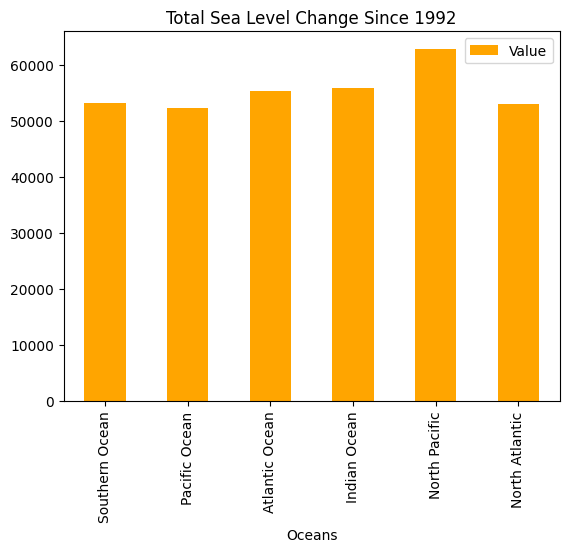

In [ ]:
msl_data2_sums.loc[['Southern Ocean', 'Pacific Ocean', 'Atlantic Ocean', 'Indian Ocean', 'North Pacific', 'North Atlantic']].plot(kind='bar', xlabel='Oceans', title='Total Sea Level Change Since 1992', color='orange')

Considering the charts above, we notice that the oceans and seas near Europe and Asia seem to have had larger changes in mean sea level. These include the Baltic Sea, South China Sea, Sea Japan, Indonesian Sea, and Persian Gulf. The North Pacific also shows the highest total sea level rise compared to the other oceans listed in this dataset.

This corresponds to the larger change in surface temperature discussed before, at least in the case of Europe.

## Exploring GHG Impact on Natural Disaster Frequency

Natural Disaster Frequency is something that varies across the globe, so we can compare the numbers of natural disasters that took place each year for countries in different continents to see if there is a noticable difference.

<Axes: >

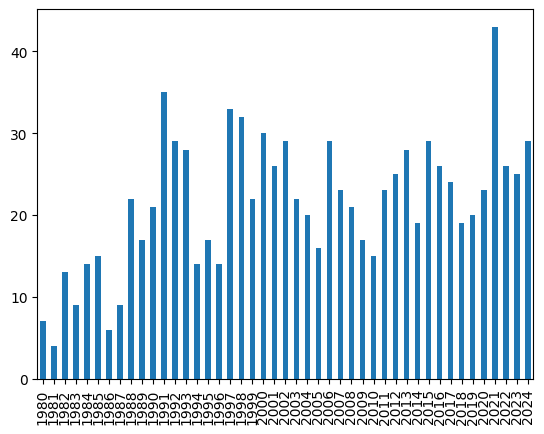

In [ ]:
ndf_data2['United States', 'Climate related disasters frequency, Number of Disasters: TOTAL'].plot(kind='bar')

<Axes: >

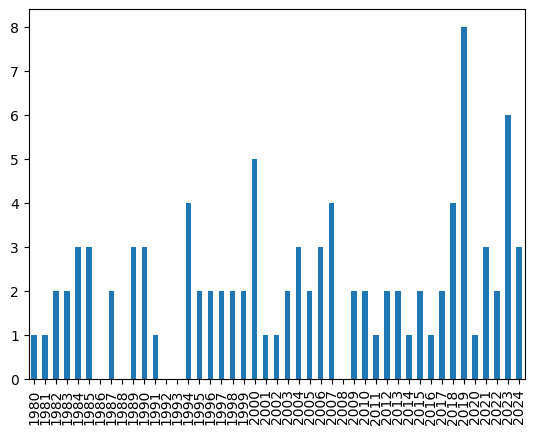

In [ ]:
ndf_data2['Spain', 'Climate related disasters frequency, Number of Disasters: TOTAL'].plot(kind='bar')

<Axes: >

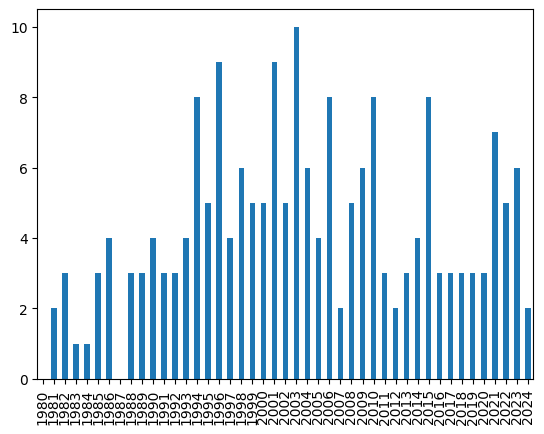

In [ ]:
ndf_data2['Australia', 'Climate related disasters frequency, Number of Disasters: TOTAL'].plot(kind='bar')

From these plots, we can see an increase in natural disaster frequency in the United States. However, there is not a very clear increase in the other countries.

This may be because there is more data for the United States than for the others. So, it might be better to look at the countries with the highest total natural disaster count for all years combined. These will be the ones with the highest number of documented natural disasters (in this dataset).

In [ ]:
ndf_total_bycountry = ndf_data3['Climate related disasters frequency, Number of Disasters: TOTAL']

<Axes: ylabel='Climate related disasters frequency, Number of Disasters: TOTAL'>

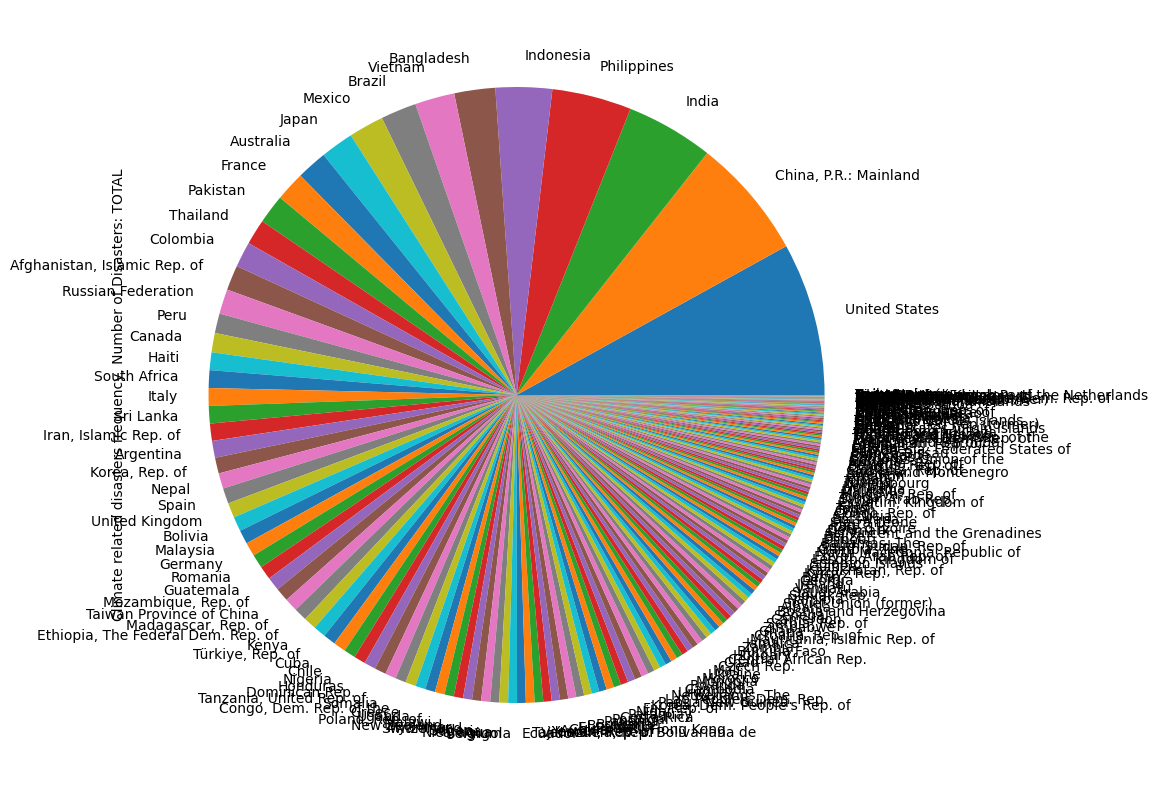

In [ ]:
ndf_total_bycountry.groupby(level=1).sum().sort_values(ascending=False).plot(kind='pie', figsize=(10,10))

In [ ]:
ndf_total_bycountry.groupby(level=1).sum().sort_values(ascending=False)[:5]

,"Climate related disasters frequency, Number of Disasters: TOTAL"
Country,
United States,968.0
"China, P.R.: Mainland",766.0
India,554.0
Philippines,503.0
Indonesia,357.0


These are the countries with the top 5 highest numbers of natural disasters for all years combined. Also, even though many of the country name labels are overlapping in the pie chart, we can still see that these are the top 5. So, data from these countries should be more wholesome and descriptive of overall trends.

<Axes: >

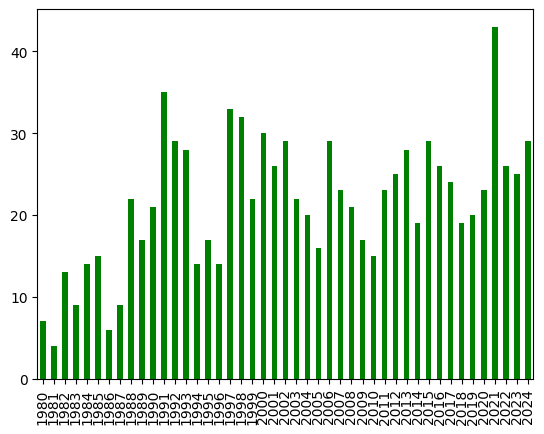

In [ ]:
ndf_data2['United States', 'Climate related disasters frequency, Number of Disasters: TOTAL'].plot(kind='bar', color='green')

<Axes: >

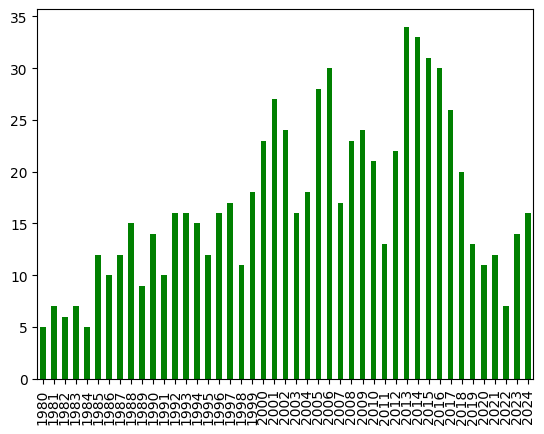

In [ ]:
ndf_data2['China, P.R.: Mainland', 'Climate related disasters frequency, Number of Disasters: TOTAL'].plot(kind='bar', color='green')

<Axes: >

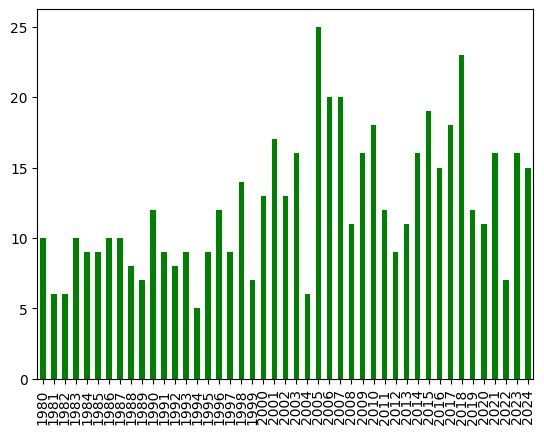

In [ ]:
ndf_data2['India', 'Climate related disasters frequency, Number of Disasters: TOTAL'].plot(kind='bar', color='green')

<Axes: >

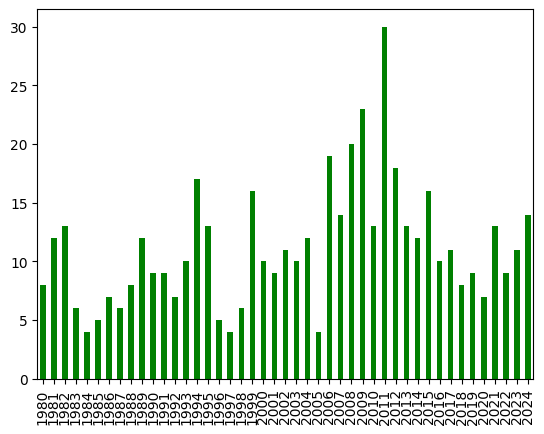

In [ ]:
ndf_data2['Philippines', 'Climate related disasters frequency, Number of Disasters: TOTAL'].plot(kind='bar', color='green')

<Axes: >

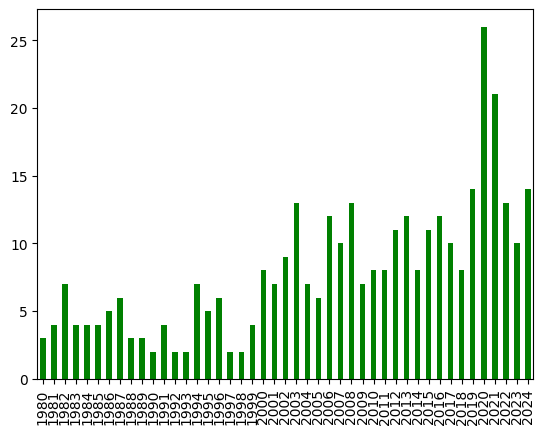

In [ ]:
ndf_data2['Indonesia', 'Climate related disasters frequency, Number of Disasters: TOTAL'].plot(kind='bar', color='green')

These graphs indicate that there have been larger numbers of natural disasters in these countries in more recent years. This points to an increase alongside other climate indicators.

To conclude, let's look at the total numbers of natural disasters over the years for all countries combined.

<Axes: >

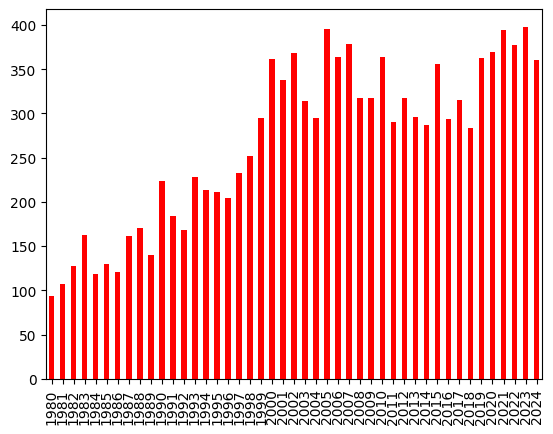

In [ ]:
ndf_total_byyear = ndf_data3['Climate related disasters frequency, Number of Disasters: TOTAL']
ndf_total_byyear.groupby(level=0).sum().plot(kind='bar', color='red')

As expected, we see a very clear increase!

## Conclusion

Altogether, we've seen that there is a strong correlation between world greenhouse gas concentrations and the climate indicators of Surface Temperature, Mean Sea Level, and Natural Disaster Frequency. These climate indicators are some of the most obvious ones that can affect our lives as time goes on.

One important finding is that Europe has seen a much larger increase in surface temperature than the other continents. We also see more sea level rise in Europe and Asia.

Another interesting finding was that the United States, China, and India had the highest numbers of documented natural disasters since 1980. In fact, these are the three most heavily populated countries in the world! This shows just how much population growth can affect climate on both regional and global scales.

There is still more to be seen, and it's especially important that we take this information into account when making plans for the future.
